In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
plantes_df = pd.read_csv("plant_growth.csv")
print(plantes_df)

    sunlight_hours    water_ml  height_cm
0         4.996321  408.897908  38.092243
1         9.605714  179.486273  41.690078
2         7.855952  102.208847  36.665302
3         6.789268  426.184571  55.195497
4         3.248149  382.742938  38.422035
..             ...         ...        ...
65        6.341569  229.281173  41.655953
66        3.127394  307.516249  35.743778
67        8.417576  381.207584  52.776075
68        2.596405  245.451841  31.139187
69        9.895095  488.712833  60.000000

[70 rows x 3 columns]


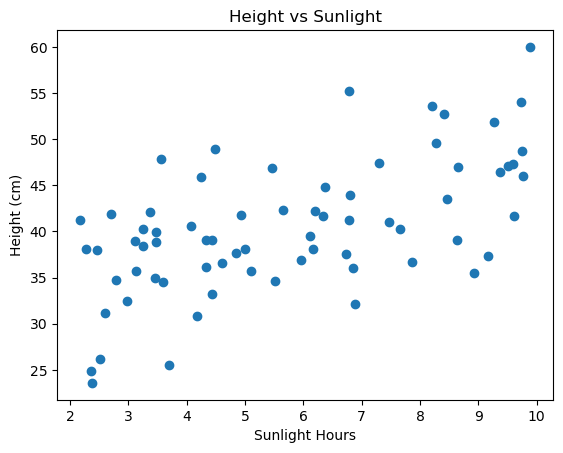

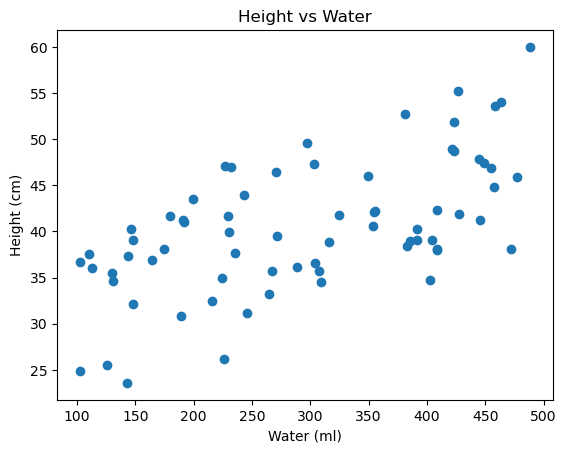

In [3]:
plt.figure()
plt.scatter(plantes_df['sunlight_hours'], plantes_df['height_cm'])
plt.xlabel('Sunlight Hours')
plt.ylabel('Height (cm)')
plt.title('Height vs Sunlight')
plt.show()

plt.figure()
plt.scatter(plantes_df['water_ml'], plantes_df['height_cm'])
plt.xlabel('Water (ml)')
plt.ylabel('Height (cm)')
plt.title('Height vs Water')
plt.show()

In [4]:
corr = plantes_df['sunlight_hours'].corr(plantes_df['height_cm'])
print(f"Correlation (sunlight vs height): {corr:.4f}")

Correlation (sunlight vs height): 0.6005


In [5]:
mean_height = plantes_df['height_cm'].mean()
print(f"Mean height: {mean_height:.2f} cm")

Mean height: 40.47 cm


In [6]:

X = plantes_df[['sunlight_hours', 'water_ml']] #i
y = plantes_df['height_cm'] #d


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_const).fit()

In [8]:

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              height_cm   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     144.4
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           3.53e-22
Time:                        19:18:29   Log-Likelihood:                -140.42
No. Observations:                  56   AIC:                             286.8
Df Residuals:                      53   BIC:                             292.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             15.8370      1.472     10.

In [9]:

sunlight_coefs = model.params['sunlight_hours']

print(f"Coefficient for sunlight_hours: {sunlight_coefs:.4f}")

Coefficient for sunlight_hours: 2.0034


In [10]:
#Activity 3, Question 1
y_preds = model.predict(X_test_const)

rmse = np.sqrt(mean_squared_error(y_test, y_preds))
print(f"RMSE: {rmse:.4f}")


RMSE: 2.9009


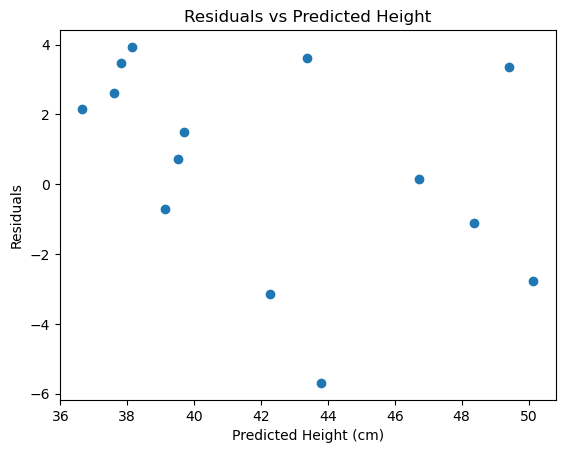

In [13]:

residuals = y_test - y_preds

plt.figure()
plt.scatter(y_preds, residuals)
plt.xlabel("Predicted Height (cm)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Height")
plt.show()

In [14]:
#Activity 3, Question 3
new_data = pd.DataFrame({
    'const': [1], 
    'sunlight_hours': [8],
    'water_ml': [350]
})

prediction = model.predict(new_data)
print(f"Predicted height (8 hrs sunlight, 350 ml water): {prediction[0]:.2f} cm")

Predicted height (8 hrs sunlight, 350 ml water): 47.22 cm
